# AURORA spectra as examples

Download 4 examples from the AURORA survey and get their S/N.

I will use these 4 examples to check the S/N estimated by the JWST ETC.

The sources I will use were shared by Alice Shapley via Slack last year. IDs are

- GOODSN-17940
- GOODSN-100067
- GOODSN-23927
- GOODSN-28209

Shapley reported the following photometry:

| Source | F115W | F125W | F150W | F160W |  r_e  | redshift |
|--------|-------|-------|-------|-------|-------|----------|
| 17940  | 25.01 | 24.97 | 24.81 | 24.81 | 0.161 | 4.4115   |
| 100067 | 25.72 | 25.66 | 25.71 | 25.71 | 0.093 | 5.1875   |
| 23927  | 25.40 | 25.48 | 25.13 | 24.70 | 0.253 | 3.3643   |
| 28209  |  na   | 24.30 |  na   | 24.01 | 0.285 | 3.2325   |

* r_e is the circularized effective radius (which should be sqrt(r_a * r_b)) and was measured on the F227W image.
* The ID is the number in the 3DHST catalog for GOODS-N

TASKS

- [x] Download the spectrum of each source
    - [x] Identifiy their ID or link for the AURORA survey.
    - [x] download the corresponding file
- [ ] Run the corresponding ETC
- [ ] Overplot the estimated S/N

In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits

In [3]:
# function to download file if not present in folder ../data/large
def download_file_if_not_present(filename, url, folder="../data/large"):
    """
    Download a file from a URL if it doesn't already exist in the specified folder.
    """ 
    import os
    import requests

    # check if file exists in folder ../data/large
    if not os.path.exists(f"{folder}/{filename}"):
        print(f"Downloading {filename} from {url}...")
        response = requests.get(url)
        with open(f"{folder}/{filename}", "wb") as f:
            f.write(response.content)
        print(f"Downloaded {filename} to {folder}")
    else:
        print(f"{filename} already exists in {folder}, skipping download.")

In [4]:
version = "v4.4" # Updated September 5, 2025.  Include all public spectra even without redshift / line fits

URL_PREFIX = "https://s3.amazonaws.com/msaexp-nirspec/extractions"
FILE_NAME = f"dja_msaexp_emission_lines_{version}.csv.gz"
table_url = f"{URL_PREFIX}/{FILE_NAME}"
download_file_if_not_present(FILE_NAME, table_url, folder="../data/large")

nirspec_table = Table.read(f"../data/large/{FILE_NAME}", format="csv").to_pandas()

dja_msaexp_emission_lines_v4.4.csv.gz already exists in ../data/large, skipping download.


In [5]:
src_id_list = [17940, 100067, 23927, 28209]

selection = nirspec_table.query("(root=='aurora-gdn01-v4' or root=='aurora-gdn02-v4') and srcid in @src_id_list and filter=='F100LP'")
selection[['file', 'srcid', 'root', 'z_best', 'zgrade', 'grade', 'comment']]

,file,srcid,root,z_best,zgrade,grade,comment
1886,aurora-gdn02-v4_g140m-f100lp_1914_100067.spec....,100067,aurora-gdn02-v4,5.188222,5.18850,3,Redshift matches aurora-gdn02-v3_g140m-f100lp_...
1898,aurora-gdn02-v4_g140m-f100lp_1914_17940.spec.fits,17940,aurora-gdn02-v4,4.412871,NaN,<NA>,NaN
1907,aurora-gdn02-v4_g140m-f100lp_1914_23927.spec.fits,23927,aurora-gdn02-v4,3.363388,3.36358,3,Redshift matches aurora-gdn02-v3_g235m-f170lp_...
1911,aurora-gdn02-v4_g140m-f100lp_1914_28209.spec.fits,28209,aurora-gdn02-v4,3.234066,3.23410,3,Redshift matches aurora-gdn02-v3_g235m-f170lp_...


In [6]:
FITS_URL = "https://s3.amazonaws.com/msaexp-nirspec/extractions/{root}/{file}"

root = selection.root.iloc[0]
fname = selection.file.iloc[0]

for root, fname in zip(selection.root, selection.file):
    # print(FITS_URL.format(root=root, file=fname))
    download_file_if_not_present(fname, FITS_URL.format(root=root, file=fname), folder="../data/large")

aurora-gdn02-v4_g140m-f100lp_1914_100067.spec.fits already exists in ../data/large, skipping download.
aurora-gdn02-v4_g140m-f100lp_1914_17940.spec.fits already exists in ../data/large, skipping download.
aurora-gdn02-v4_g140m-f100lp_1914_23927.spec.fits already exists in ../data/large, skipping download.
aurora-gdn02-v4_g140m-f100lp_1914_28209.spec.fits already exists in ../data/large, skipping download.


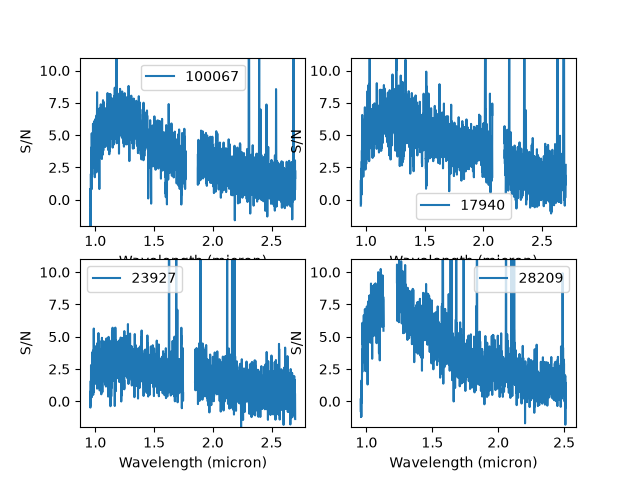

In [7]:
a = fits.open('../data/large/aurora-gdn02-v4_g140m-f100lp_1914_17940.spec.fits')

plt.figure(1)
plt.clf()

ax_list = plt.subplots(nrows=2, ncols=2, num=1, clear=True)[1].flatten()

for ax, fname in zip(ax_list, selection.file):
    idx = fname.split('_')[-1].split('.')[0]
    with fits.open(f'../data/large/{fname}') as spec1d:
        ax.plot(spec1d[1].data['wave'], spec1d[1].data['flux'] / spec1d[1].data['err'], label=idx)
    ax.legend()
    ax.set_xlabel('Wavelength (micron)')
    ax.set_ylabel('S/N')
    ax.set_ylim(-2, 11)

plt.show()